## Enriquecimiento de Productos con Regex (Fase 1)

### Por: Grupo 12 - ITBA
### Fecha: 2026-04-01

### Descripcion:
Extraccion de atributos del campo Description usando expresiones regulares. Se trabaja a nivel producto unico (3,877 descripciones) para generar flags binarios por color, material, tamano, estilo y extraccion de quantity_in_set.

## Importar librerias

In [1]:
import re
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

## Cargar datos y extraer productos unicos

In [2]:
df = pd.read_parquet("../../data/03_primary/ventas_limpias.parquet")
print(f"Registros totales: {len(df):,}")

# Extraer productos unicos
productos = df[['Description']].drop_duplicates().reset_index(drop=True)
print(f"Productos unicos: {len(productos):,}")

Registros totales: 397,884
Productos unicos: 3,877


## Definir patrones regex

In [3]:
# Colores (15 colores detectados en exploracion)
COLORS = ['RED', 'PINK', 'WHITE', 'BLUE', 'IVORY', 'CREAM', 'GREEN', 'BLACK', 
          'SILVER', 'YELLOW', 'PURPLE', 'GREY', 'ORANGE', 'GOLD', 'BROWN']

# Materiales (13 materiales)
MATERIALS = ['TIN', 'WOOD', 'METAL', 'PAPER', 'WOODEN', 'GLASS', 'CERAMIC', 
             'ZINC', 'COTTON', 'WOOL', 'KNITTED', 'FABRIC', 'PLASTIC']

# Tamanos (6 tamanos)
SIZES = ['JUMBO', 'SMALL', 'LARGE', 'MINI', 'GIANT', 'MEDIUM']

# Estilos (9 estilos)
STYLES = ['RETROSPOT', 'VINTAGE', 'POLKADOT', 'SPACEBOY', 'SKULLS', 
          'REGENCY', 'PAISLEY', 'WOODLAND', 'UNION JACK']

# Productos no validos
NON_PRODUCTS = ['POSTAGE', 'MANUAL', 'DOTCOM POSTAGE', 'BANK CHARGES', 'SAMPLES']

# Pattern para sets/packs
SET_PATTERN = r'(SET|PACK|BOX)\s+OF\s+(\d+)'

## Funciones de extraccion

In [4]:
def extract_colors(desc):
    """Extrae todos los colores presentes en la descripcion"""
    if pd.isna(desc):
        return []
    desc_upper = desc.upper()
    found = [color for color in COLORS if re.search(rf'\b{color}\b', desc_upper)]
    return found

def extract_materials(desc):
    """Extrae todos los materiales presentes en la descripcion"""
    if pd.isna(desc):
        return []
    desc_upper = desc.upper()
    found = [mat for mat in MATERIALS if re.search(rf'\b{mat}\b', desc_upper)]
    return found

def extract_sizes(desc):
    """Extrae todos los tamanos presentes en la descripcion"""
    if pd.isna(desc):
        return []
    desc_upper = desc.upper()
    found = [size for size in SIZES if re.search(rf'\b{size}\b', desc_upper)]
    return found

def extract_styles(desc):
    """Extrae todos los estilos presentes en la descripcion"""
    if pd.isna(desc):
        return []
    desc_upper = desc.upper()
    found = [style for style in STYLES if re.search(rf'\b{style}\b', desc_upper)]
    return found

def extract_quantity_in_set(desc):
    """Extrae la cantidad si es un set/pack/box"""
    if pd.isna(desc):
        return None, None
    match = re.search(SET_PATTERN, desc.upper())
    if match:
        return match.group(1), int(match.group(2))
    return None, None

def is_valid_product(desc):
    """Verifica si es un producto valido (no es POSTAGE, etc.)"""
    if pd.isna(desc):
        return False
    desc_upper = desc.upper()
    return not any(non_prod in desc_upper for non_prod in NON_PRODUCTS)

In [5]:
# Aplicar funciones
productos['colors_list'] = productos['Description'].apply(extract_colors)
productos['materials_list'] = productos['Description'].apply(extract_materials)
productos['sizes_list'] = productos['Description'].apply(extract_sizes)
productos['styles_list'] = productos['Description'].apply(extract_styles)
productos[['set_type', 'quantity_in_set']] = productos['Description'].apply(
    lambda x: pd.Series(extract_quantity_in_set(x))
)
productos['is_valid_product'] = productos['Description'].apply(is_valid_product)

print("Extraccion completada")

Extraccion completada


## Crear flags binarios por color

In [6]:
for color in COLORS:
    productos[f'has_{color.lower()}'] = productos['colors_list'].apply(
        lambda x: color in x
    )

productos['has_color'] = productos['colors_list'].apply(len) > 0
print(f"Productos con color: {productos['has_color'].sum()} ({productos['has_color'].mean()*100:.2f}%)")

Productos con color: 1326 (34.20%)


## Crear flags binarios por material

In [7]:
for material in MATERIALS:
    productos[f'has_{material.lower()}'] = productos['materials_list'].apply(
        lambda x: material in x
    )

productos['has_material'] = productos['materials_list'].apply(len) > 0
print(f"Productos con material: {productos['has_material'].sum()} ({productos['has_material'].mean()*100:.2f}%)")

Productos con material: 610 (15.73%)


## Crear flags binarios por tamano y estilo

In [8]:
for size in SIZES:
    productos[f'has_{size.lower()}'] = productos['sizes_list'].apply(
        lambda x: size in x
    )

for style in STYLES:
    style_col = style.lower().replace(' ', '_')
    productos[f'has_{style_col}'] = productos['styles_list'].apply(
        lambda x: style in x
    )

productos['has_size'] = productos['sizes_list'].apply(len) > 0
productos['has_style'] = productos['styles_list'].apply(len) > 0
productos['is_set'] = productos['quantity_in_set'].notna()

print(f"Productos con tamano: {productos['has_size'].sum()} ({productos['has_size'].mean()*100:.2f}%)")
print(f"Productos con estilo: {productos['has_style'].sum()} ({productos['has_style'].mean()*100:.2f}%)")
print(f"Productos que son sets: {productos['is_set'].sum()} ({productos['is_set'].mean()*100:.2f}%)")

Productos con tamano: 325 (8.38%)
Productos con estilo: 525 (13.54%)
Productos que son sets: 193 (4.98%)


## Calcular metricas agregadas

In [9]:
productos['n_attributes'] = (
    productos['has_color'].astype(int) + 
    productos['has_material'].astype(int) + 
    productos['has_size'].astype(int) + 
    productos['has_style'].astype(int) + 
    productos['is_set'].astype(int)
)

productos['needs_llm'] = (productos['n_attributes'] == 0) & productos['is_valid_product']

print("\nDistribucion de atributos detectados:")
print(productos['n_attributes'].value_counts().sort_index())
print(f"\nProductos que necesitan LLM: {productos['needs_llm'].sum()} ({productos['needs_llm'].mean()*100:.2f}%)")
print(f"Productos no validos: {(~productos['is_valid_product']).sum()}")


Distribucion de atributos detectados:
n_attributes
0    1563
1    1702
2     559
3      53
Name: count, dtype: int64

Productos que necesitan LLM: 1559 (40.21%)
Productos no validos: 4


## Validacion de cobertura

In [10]:
cobertura = pd.DataFrame({
    'Atributo': ['Color', 'Material', 'Tamano', 'Estilo', 'Set'],
    'Esperado': ['26.46%', '18.72%', '10.53%', '17.83%', '8.41%'],
    'Obtenido': [
        f"{productos['has_color'].mean()*100:.2f}%",
        f"{productos['has_material'].mean()*100:.2f}%",
        f"{productos['has_size'].mean()*100:.2f}%",
        f"{productos['has_style'].mean()*100:.2f}%",
        f"{productos['is_set'].mean()*100:.2f}%"
    ]
})

print("\nComparacion con exploracion previa (a nivel transaccion):")
print(cobertura.to_string(index=False))


Comparacion con exploracion previa (a nivel transaccion):
Atributo Esperado Obtenido
   Color   26.46%   34.20%
Material   18.72%   15.73%
  Tamano   10.53%    8.38%
  Estilo   17.83%   13.54%
     Set    8.41%    4.98%


## Guardar tabla enriquecida

In [11]:
FEATURE_PATH = Path("../../data/04_feature/")
FEATURE_PATH.mkdir(parents=True, exist_ok=True)

productos.to_parquet(FEATURE_PATH / "productos_enriquecidos_regex.parquet", index=False)

print(f"Archivo guardado: productos_enriquecidos_regex.parquet")
print(f"Dimensiones: {productos.shape}")
print(f"Columnas totales: {len(productos.columns)}")

Archivo guardado: productos_enriquecidos_regex.parquet
Dimensiones: (3877, 58)
Columnas totales: 58


## Visualizaciones del Enriquecimiento

Se generan graficos basicos para documentar el proceso de enriquecimiento del dataset y preparar el analisis posterior.

### 1. Cobertura de Atributos por Producto

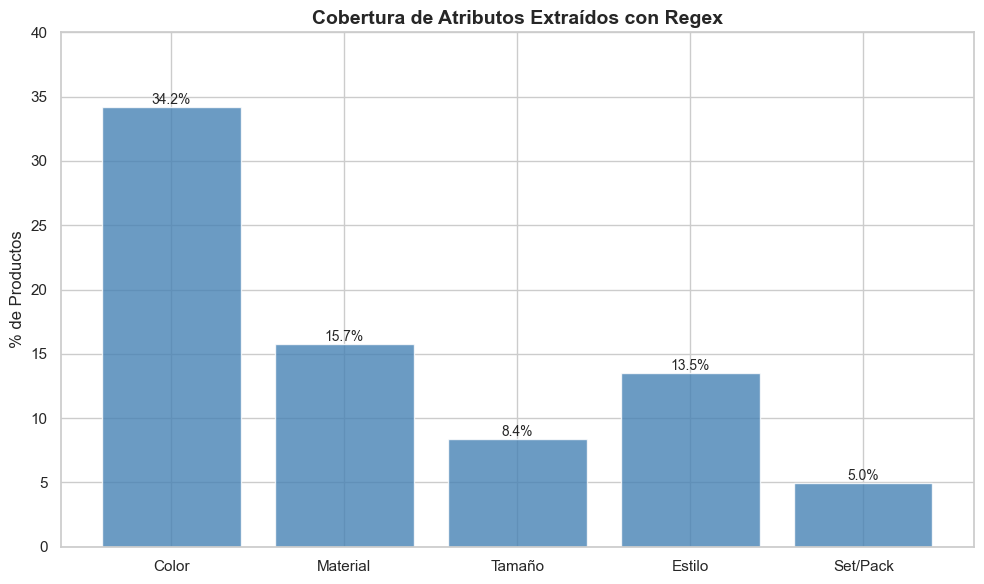

Grafico 1 guardado: product_attributes_coverage.png


In [12]:
REPORTING_PATH = Path("../../data/08_reporting/")
REPORTING_PATH.mkdir(parents=True, exist_ok=True)

# Grafico 1: Cobertura de atributos
fig, ax = plt.subplots(figsize=(10, 6))

cobertura_data = {
    'Color': productos['has_color'].mean() * 100,
    'Material': productos['has_material'].mean() * 100,
    'Tamaño': productos['has_size'].mean() * 100,
    'Estilo': productos['has_style'].mean() * 100,
    'Set/Pack': productos['is_set'].mean() * 100
}

bars = ax.bar(cobertura_data.keys(), cobertura_data.values(), color='steelblue', alpha=0.8)
ax.set_ylabel('% de Productos', fontsize=12)
ax.set_title('Cobertura de Atributos Extraídos con Regex', fontsize=14, fontweight='bold')
ax.set_ylim(0, 40)

# Agregar valores en las barras
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}%',
            ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig(REPORTING_PATH / "product_attributes_coverage.png", dpi=300, bbox_inches='tight')
plt.show()

print("Grafico 1 guardado: product_attributes_coverage.png")

### 2. Distribucion de Numero de Atributos por Producto

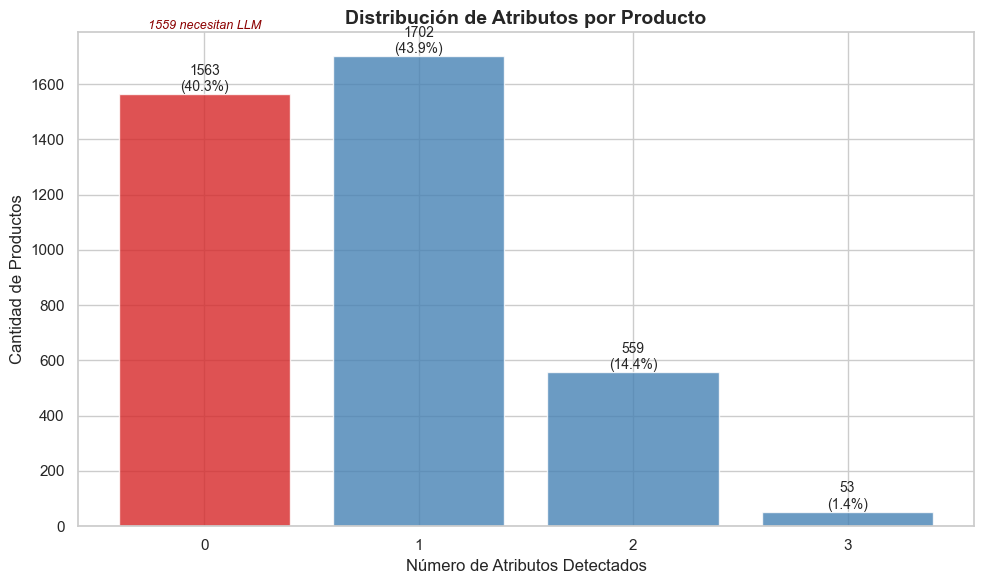

Grafico 2 guardado: product_attributes_distribution.png


In [13]:
# Grafico 2: Distribucion de n_attributes
fig, ax = plt.subplots(figsize=(10, 6))

attr_counts = productos['n_attributes'].value_counts().sort_index()
colors_palette = ['#d62728' if x == 0 else 'steelblue' for x in attr_counts.index]

bars = ax.bar(attr_counts.index, attr_counts.values, color=colors_palette, alpha=0.8)
ax.set_xlabel('Número de Atributos Detectados', fontsize=12)
ax.set_ylabel('Cantidad de Productos', fontsize=12)
ax.set_title('Distribución de Atributos por Producto', fontsize=14, fontweight='bold')
ax.set_xticks(range(0, 4))

# Agregar valores y porcentajes
for i, bar in enumerate(bars):
    height = bar.get_height()
    pct = (height / len(productos)) * 100
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=10)

# Nota especial para productos sin atributos
ax.text(0, attr_counts[0] * 1.15, 
        f'{productos["needs_llm"].sum()} necesitan LLM',
        ha='center', fontsize=9, color='darkred', style='italic')

plt.tight_layout()
plt.savefig(REPORTING_PATH / "product_attributes_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

print("Grafico 2 guardado: product_attributes_distribution.png")

### 3. Top 10 Colores Mas Frecuentes

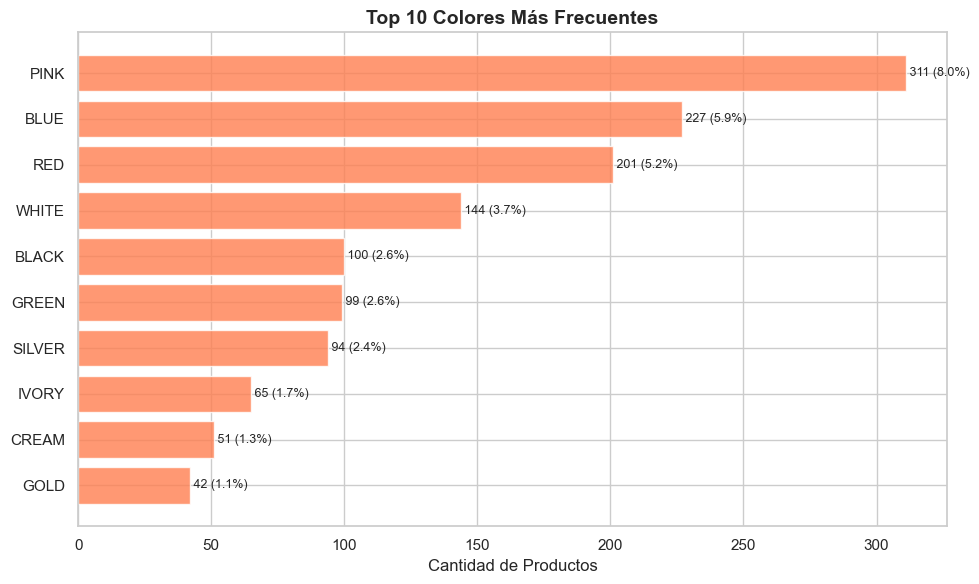

Grafico 3 guardado: top_colors_frequency.png


In [14]:
# Grafico 3: Top colores
color_counts = {}
for color in COLORS:
    color_counts[color] = productos[f'has_{color.lower()}'].sum()

top_colors = sorted(color_counts.items(), key=lambda x: x[1], reverse=True)[:10]

fig, ax = plt.subplots(figsize=(10, 6))
colors_names = [c[0] for c in top_colors]
colors_values = [c[1] for c in top_colors]

bars = ax.barh(colors_names, colors_values, color='coral', alpha=0.8)
ax.set_xlabel('Cantidad de Productos', fontsize=12)
ax.set_title('Top 10 Colores Más Frecuentes', fontsize=14, fontweight='bold')
ax.invert_yaxis()

# Agregar valores y porcentajes
for i, bar in enumerate(bars):
    width = bar.get_width()
    pct = (width / len(productos)) * 100
    ax.text(width, bar.get_y() + bar.get_height()/2.,
            f' {int(width)} ({pct:.1f}%)',
            ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(REPORTING_PATH / "top_colors_frequency.png", dpi=300, bbox_inches='tight')
plt.show()

print("Grafico 3 guardado: top_colors_frequency.png")

### 4. Top 10 Materiales Mas Frecuentes

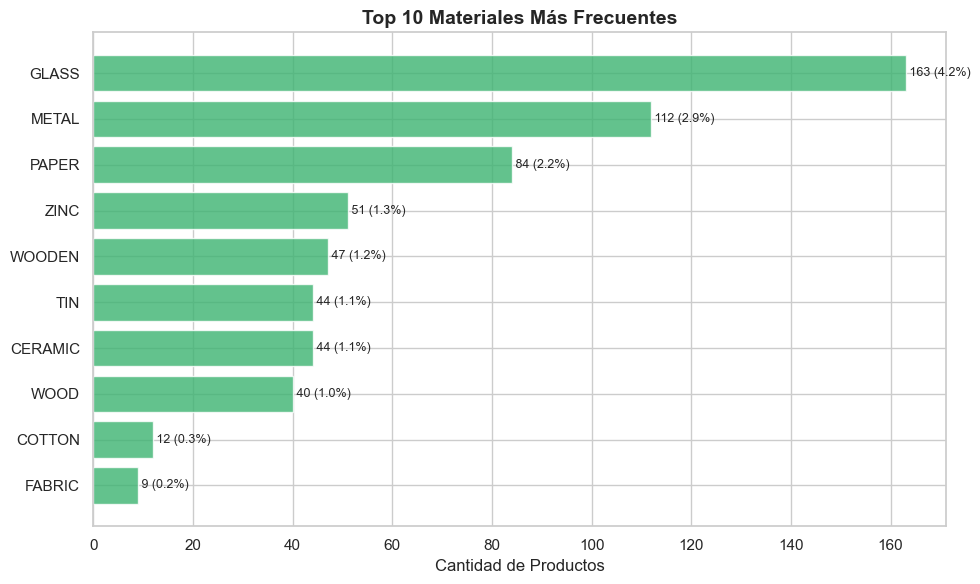

Grafico 4 guardado: top_materials_frequency.png


In [15]:
# Grafico 4: Top materiales
material_counts = {}
for material in MATERIALS:
    material_counts[material] = productos[f'has_{material.lower()}'].sum()

top_materials = sorted(material_counts.items(), key=lambda x: x[1], reverse=True)[:10]

fig, ax = plt.subplots(figsize=(10, 6))
materials_names = [m[0] for m in top_materials]
materials_values = [m[1] for m in top_materials]

bars = ax.barh(materials_names, materials_values, color='mediumseagreen', alpha=0.8)
ax.set_xlabel('Cantidad de Productos', fontsize=12)
ax.set_title('Top 10 Materiales Más Frecuentes', fontsize=14, fontweight='bold')
ax.invert_yaxis()

# Agregar valores y porcentajes
for i, bar in enumerate(bars):
    width = bar.get_width()
    pct = (width / len(productos)) * 100
    ax.text(width, bar.get_y() + bar.get_height()/2.,
            f' {int(width)} ({pct:.1f}%)',
            ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(REPORTING_PATH / "top_materials_frequency.png", dpi=300, bbox_inches='tight')
plt.show()

print("Grafico 4 guardado: top_materials_frequency.png")

## Resumen del Enriquecimiento

**Resultados obtenidos:**
- **34.20%** de productos tienen color explícito
- **15.73%** tienen material explícito
- **8.38%** tienen tamaño explícito
- **13.54%** tienen estilo explícito
- **4.98%** son sets/packs con cantidad

**Productos con al menos 1 atributo:** 2,314 (59.68%)

**Productos sin atributos detectables (necesitan LLM):** 1,559 (40.21%)

**Próximos pasos:**
1. Join con dataset de transacciones para análisis enriquecido
2. Enriquecimiento con LLM para el 40% restante (Fase 2)
3. Feature engineering avanzado para modelado